In [ ]:
# In this notebook I simulate Grover's Algorithm in an n-qubit database, including error simulators.

In [1]:
!pip install qiskit numpy matplotlib qiskit[visualization] qiskit-aer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.5 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=ee2eaae1b954111befb9102fd22254b175cc8848ef09db0834021e4e071de328
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import PhaseOracleGate
from qiskit.circuit.library import grover_operator
from qiskit_aer import AerSimulator
from qiskit_aer.noise import depolarizing_error, NoiseModel, pauli_error, thermal_relaxation_error, ReadoutError
from qiskit.compiler import transpile
import numpy as np
import matplotlib.pyplot as plt
import math

In [3]:
# Creating noise models for three different types of noise

def make_depolarizing():
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(0.001, 1), ['h', 'x', 'u1', 'u2', 'u3'])
    nm.add_all_qubit_quantum_error(depolarizing_error(0.01,  2), ['cx', 'cz'])
    return nm

def make_thermal():
    nm = NoiseModel()
    T1, T2 = 50_000, 70_000
    therm_1q = thermal_relaxation_error(T1, T2, 50)
    therm_2q = thermal_relaxation_error(T1, T2, 300).expand(
               thermal_relaxation_error(T1, T2, 300))
    nm.add_all_qubit_quantum_error(therm_1q, ['h', 'x', 'u1', 'u2', 'u3'])
    nm.add_all_qubit_quantum_error(therm_2q, ['cx', 'cz'])
    return nm

def make_readout():
    nm = NoiseModel()
    p = 0.02
    nm.add_all_qubit_readout_error(ReadoutError([[1-p, p], [p, 1-p]]))
    return nm

In [4]:
# This cell is for determining parameters of the algorithm, including how many qubits the circuit will have
n = 5

Target = np.random.randint(low=0, high=2, size=n)
print(Target)
# This creates a random bitstring that we will be searching for with Grover's Algorithm

[1 1 0 0 0]


In [5]:
# We will now create the argument for the phase oracle gate

TargetExpression = ""
for i in range(n):
  if Target[i] == 1:
    TargetExpression += "x" + str(i) + " & "
  elif Target[i] == 0:
    TargetExpression += "~x" + str(i) + " & "

TargetExpression = TargetExpression[:-2]
# removes the & at the end

print(TargetExpression)

x0 & x1 & ~x2 & ~x3 & ~x4 


x0&x1&x2&x3&x
{'11111': 99926, '01110': 2, '10101': 2, '10010': 2, '11110': 3, '11000': 3, '00111': 1, '01100': 2, '11101': 6, '00100': 3, '01000': 5, '00011': 5, '10111': 1, '00110': 2, '01011': 4, '10001': 2, '00001': 2, '10000': 2, '01111': 1, '11100': 6, '10100': 4, '11010': 3, '00010': 1, '10110': 2, '01001': 1, '10011': 2, '00101': 2, '00000': 2, '11001': 2, '11011': 1}


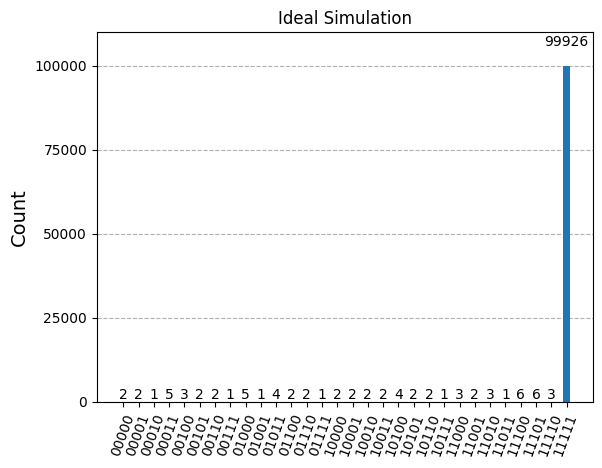

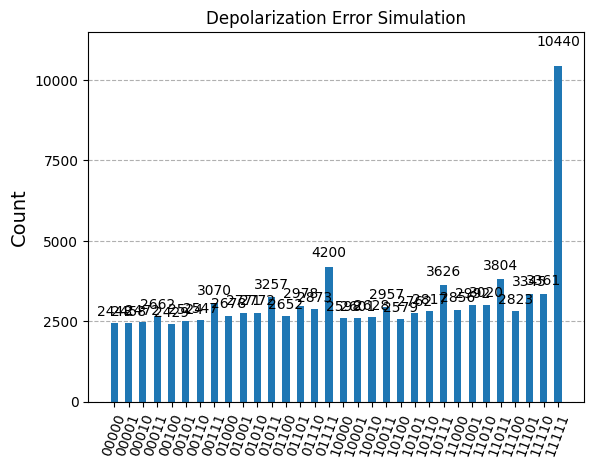

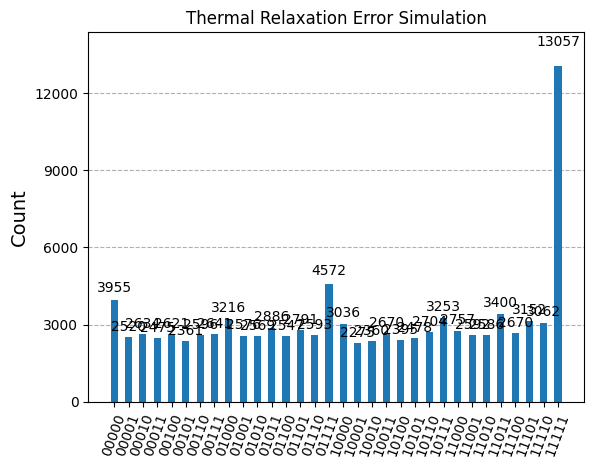

{'11111': 99926, '01110': 2, '10101': 2, '10010': 2, '11110': 3, '11000': 3, '00111': 1, '01100': 2, '11101': 6, '00100': 3, '01000': 5, '00011': 5, '10111': 1, '00110': 2, '01011': 4, '10001': 2, '00001': 2, '10000': 2, '01111': 1, '11100': 6, '10100': 4, '11010': 3, '00010': 1, '10110': 2, '01001': 1, '10011': 2, '00101': 2, '00000': 2, '11001': 2, '11011': 1}


{'10011': 2957, '01010': 2772, '11100': 2823, '10101': 2762, '10010': 2628, '00110': 2547, '00001': 2458, '01000': 2678, '01100': 2652, '11101': 3345, '10111': 3626, '10100': 2579, '01011': 3257, '11000': 2856, '00100': 2429, '01110': 2873, '11110': 3361, '01101': 2978, '00010': 2472, '11010': 3020, '00101': 2524, '01001': 2771, '10001': 2601, '10000': 2598, '11111': 10440, '11011': 3804, '00111': 3070, '00011': 2662, '10110': 2817, '11001': 2992, '00000': 2448, '01111': 4200}


{'01110': 2593, '01001': 2576, '01000': 3216, '01100': 2547, '00111': 2641, '00011': 2475, '11101': 3152, '01011': 2886, '10001': 2275, '00101': 2361

In [6]:
# Here is the actual implementation of Grover's Algorithm

#IMPORTANT: For simulation purposes, make the target string the last bitstring (1111....1)
TargetExpression = ""
for i in range(n):
  TargetExpression += ("x" + str(i) + "&")

TargetExpression = TargetExpression[:-2]
print(TargetExpression)


Grovers = QuantumCircuit(n)

Grovers.h(range(n))
#Prepares all qubits in the "+" state.
for i in range(int(math.ceil(((math.pi)/4*(math.sqrt(2**n)))))-1):
# Calculates how many times Grover's operation needs to be applied to statistically "guarantee" a correct answer if the algorithm is repeated several times

  Grovers = Grovers.compose(grover_operator(PhaseOracleGate(TargetExpression)), range(n))
  # Repeat the phase oracle and diffusion steps 27 times (when n = 10). 27 is approximately the number of iterations to optimally converge
  # Grover's Algorithm needs pi/4 * sqrt(2^n) = 25.13 iterations to converge a statistically significant amount (minimizing incorrect results)


# Measure and record our qubits' states ideal
Grovers.measure_all()
sampler = StatevectorSampler()
result = sampler.run([Grovers], shots = 100000).result()
ideal_counts = result[0].data.meas.get_counts()
print(result[0].data.meas.get_counts())


# Measure and record our qubits' states (depolarization error)

backend = AerSimulator(noise_model=make_depolarizing())
transpiled = transpile(Grovers, backend)
job = backend.run(transpiled, shots= 100000)
depolarizing_counts = job.result().get_counts()

# Meaure and record qubits with thermal relaxation error

backend = AerSimulator(noise_model = make_thermal())
transpiled = transpile(Grovers, backend)
job = backend.run(transpiled, shots = 100000)
thermal_counts = job.result().get_counts()


# Measure and record qubits with readout error

backend =AerSimulator(noise_model = make_readout())
transpiled =  transpile(Grovers, backend)
job = backend.run(transpiled, shots = 100000)
readout_counts = job.result().get_counts()
# Plot separate histograms

fig1, ax1 = plt.subplots()
plot_histogram(ideal_counts, ax=ax1, title="Ideal Simulation")

fig2, ax2 = plt.subplots()
plot_histogram(depolarizing_counts, ax=ax2, title="Depolarization Error Simulation")

fig3, ax3 = plt.subplots()
plot_histogram(thermal_counts, ax=ax3, title = "Thermal Relaxation Error Simulation")

fig4, ax4 = plt.subplots()
plot_histogram(readout_counts, ax=ax4, title = "Readout Error Simulation")

plt.close()
plt.show()

print(ideal_counts )
print('\n')
print(depolarizing_counts )
print('\n')
print(thermal_counts )
print('\n')
print(readout_counts )
print('\n')

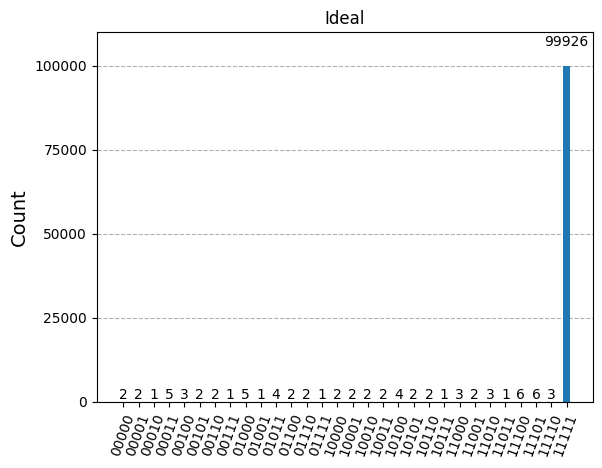

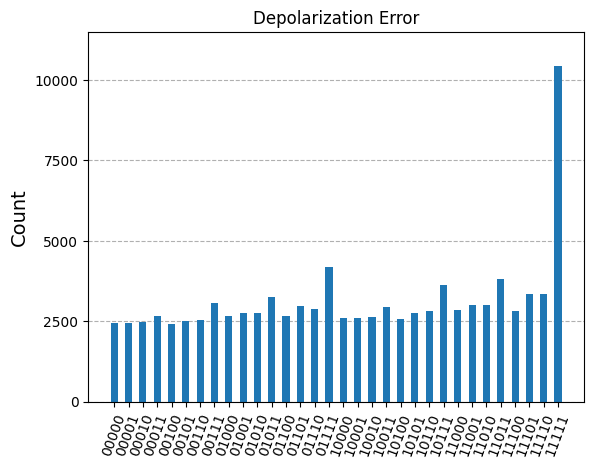

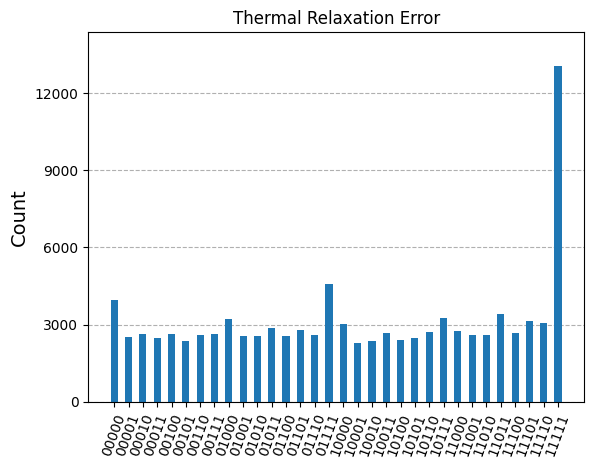

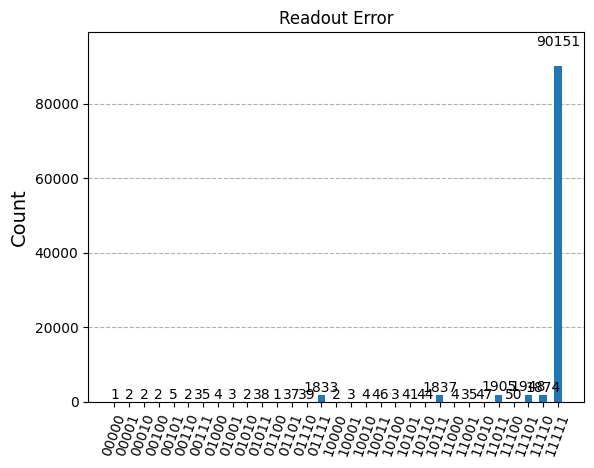

In [7]:
#plot separate histograms

fig1, ax1 = plt.subplots()
plot_histogram(ideal_counts, ax=ax1, title="Ideal", figsize = (20,8))

fig2, ax2 = plt.subplots()
plot_histogram(depolarizing_counts, ax=ax2, title="Depolarization Error",bar_labels = False, figsize = (20,8))

fig3, ax3 = plt.subplots()
plot_histogram(thermal_counts, ax=ax3, title = "Thermal Relaxation Error",bar_labels = False, figsize = (20,8))

fig4, ax4 = plt.subplots()
plot_histogram(readout_counts, ax=ax4, title = "Readout Error", figsize = (20,8))
plt.show()

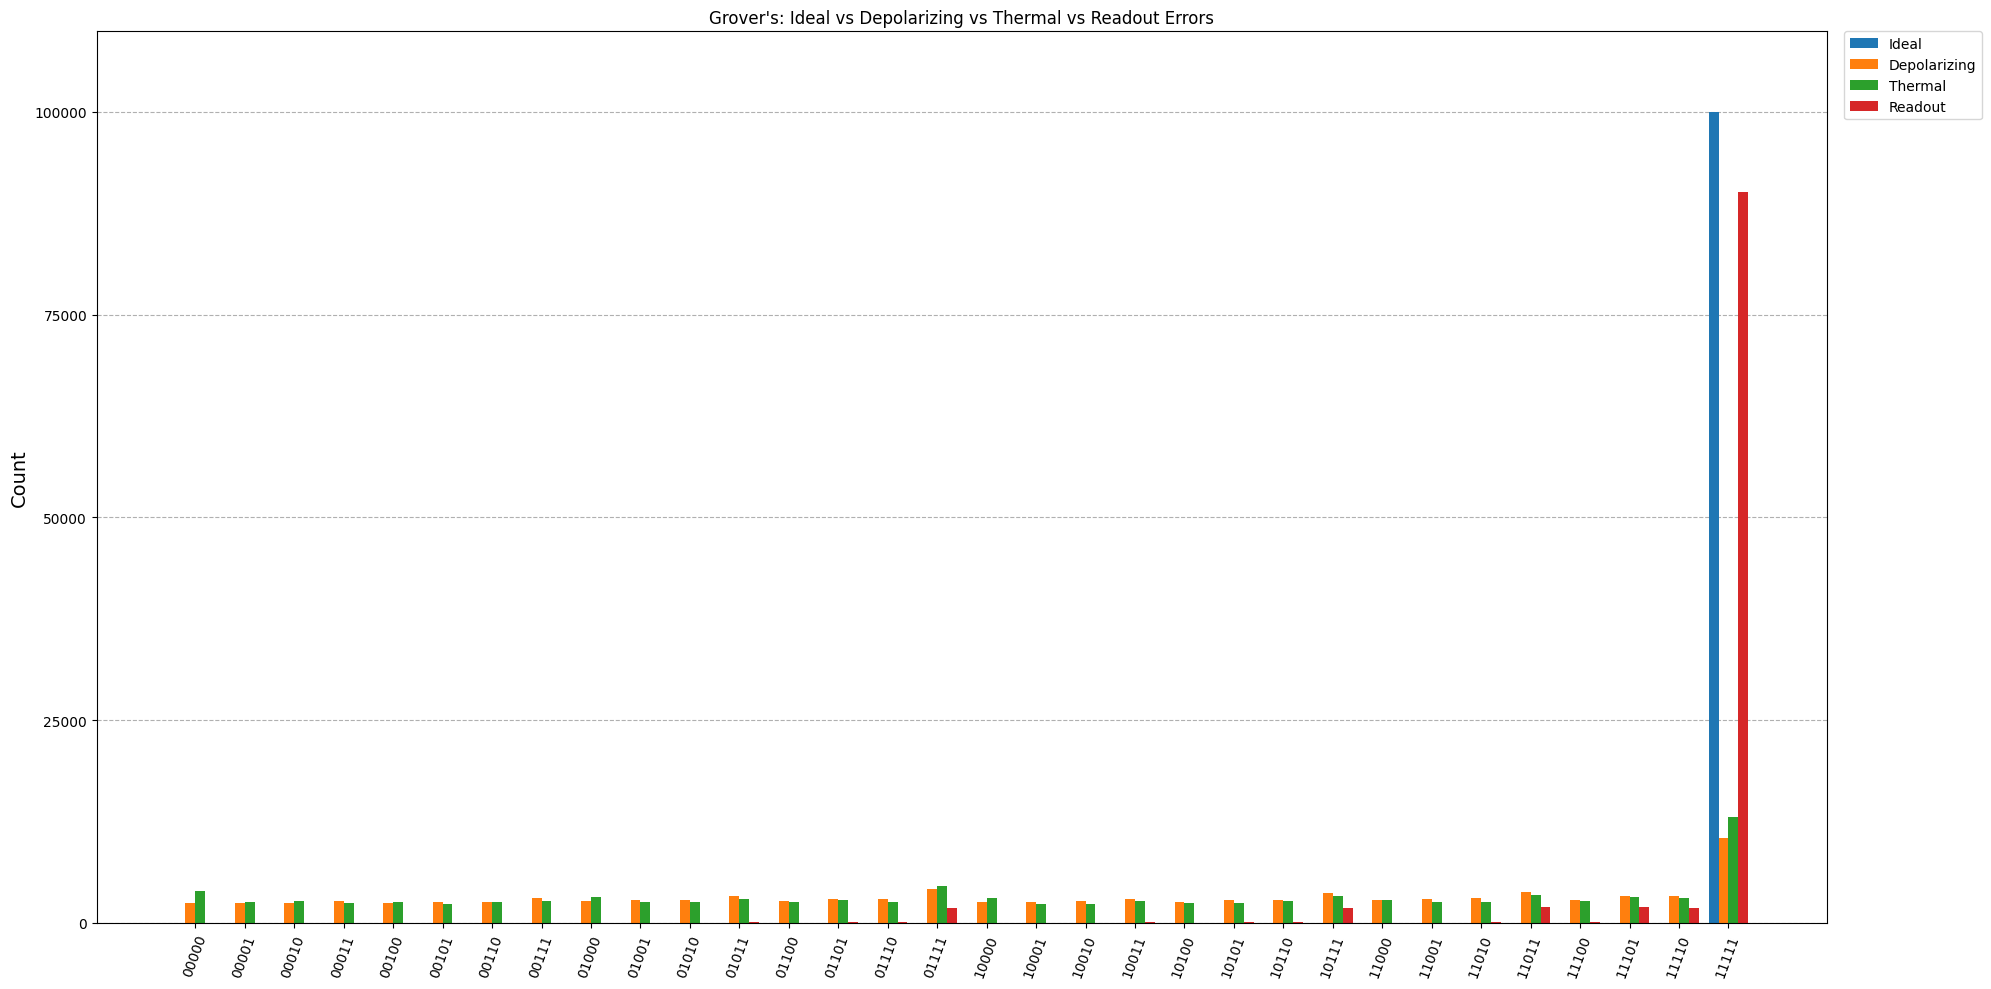

In [8]:
#Plot all histograms together

plot_histogram(
    [ideal_counts, depolarizing_counts, thermal_counts, readout_counts],
    legend=["Ideal", "Depolarizing", "Thermal", "Readout"],
    title="Grover's: Ideal vs Depolarizing vs Thermal vs Readout Errors",
    bar_labels=False, figsize=(20,10)
)


We see that depolarization error causes the greatest inaccuracy, followed by thermal relaxation. This makes sense theoretically, as the information in the system is stored in the amplitudes of the state vector. Additionally, readout error is relatively small as there is only one instance where redout error can occur: at the end of the circuit.

In [ ]:
# Additionally we can draw the Circuit
Grovers.draw(output = "mpl")
# This can be a large drawing for large n